# Data Analysis

Simple analysis to the data that we worked with

## Imports

In [30]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

## Paths

In [31]:
path_data = "../../data/"
raw_data = path_data + "raw_data/DeepTMHMM.3line"
train_dataset_fused_80 = path_data + "train_test_data/hobohm1_ole_formula/train_dataset_fused_80.0%.txt"

## Functions

In [32]:
def count_occurrences(filepath, alphabet="ACDEFGHIKLMNPQRSTVWY"):
    """
    Counts amino acid and state occurrences from a fasta file.

    Parameters
    ----------
    filepath : str
        Path to the fasta file.
    alphabet : str
        Valid amino acid symbols.

    Returns
    -------
    aa_counts : dict
        Total count of each amino acid.
    state_counts : dict
        Total count of each state label.
    transition_counts : dict
        Count of each state->state transition.
    """

    aa_counts = Counter()
    state_counts = Counter()
    transition_counts = Counter()

    with open(filepath, "r") as f:
        lines = [l.strip() for l in f.readlines()]

    i = 0
    while i < len(lines):
        if lines[i].startswith(">"):
            seq = lines[i+1]
            lab = lines[i+2]

            # count amino acids
            for aa in seq:
                if aa in alphabet:
                    aa_counts[aa] += 1

            # count states
            for state in lab:
                state_counts[state] += 1

            # count transitions
            for t in range(len(lab) - 1):
                transition_counts[(lab[t], lab[t+1])] += 1

            i += 3
        else:
            i += 1

    # print summary
    print("=== STATE COUNTS ===")
    total_states = sum(state_counts.values())
    for state, count in sorted(state_counts.items()):
        print(f"  {state}: {count:6d} ({100*count/total_states:.2f}%)")

    print("\n=== AMINO ACID COUNTS ===")
    total_aa = sum(aa_counts.values())
    for aa, count in sorted(aa_counts.items()):
        print(f"  {aa}: {count:6d} ({100*count/total_aa:.2f}%)")

    return aa_counts, state_counts, transition_counts

In [33]:
def analyze_signal_peptide_position(filepath, alphabet="ACDEFGHIKLMNPQRSTVWY"):
    """
    Analyzes the relative position of signal peptide (S) labels in sequences.

    Parameters
    ----------
    filepath : str
        Path to the fasta file.
    alphabet : str
        Valid amino acid symbols.

    Returns
    -------
    relative_positions : list of float
        Relative positions (0-1) of S labels across all sequences.
    """

    relative_positions = []
    s_lengths = []

    with open(filepath, "r") as f:
        lines = [l.strip() for l in f.readlines()]

    i = 0
    n_with_s = 0
    n_without_s = 0

    while i < len(lines):
        if lines[i].startswith(">"):
            seq = lines[i+1]
            lab = lines[i+2]
            T = len(lab)

            if "S" in lab:
                n_with_s += 1
                s_positions = [t for t, state in enumerate(lab) if state == "S"]
                s_lengths.append(len(s_positions))

                # relative positions of S in the sequence
                for pos in s_positions:
                    relative_positions.append(pos / T)
            else:
                n_without_s += 1

            i += 3
        else:
            i += 1

    print(f"Sequences with S:    {n_with_s}")
    print(f"Sequences without S: {n_without_s}")
    print(f"Avg S length:        {np.mean(s_lengths):.1f} residues")
    print(f"Min S length:        {np.min(s_lengths)}")
    print(f"Max S length:        {np.max(s_lengths)}")
    print(f"Avg relative start:  {np.min(relative_positions):.3f}")
    print(f"Avg relative end:    {np.max([p for p in relative_positions]):.3f}")

    return relative_positions, s_lengths

## Results

In [34]:
aa_counts_raw, state_counts_raw, transition_counts_raw = count_occurrences(raw_data)

=== STATE COUNTS ===
  B:  11604 (0.63%)
  I: 1269655 (68.85%)
  M:  58206 (3.16%)
  O: 457255 (24.80%)
  P:  18782 (1.02%)
  S:  28525 (1.55%)

=== AMINO ACID COUNTS ===
  A: 131722 (7.14%)
  C:  31257 (1.70%)
  D:  97646 (5.30%)
  E: 121977 (6.61%)
  F:  71233 (3.86%)
  G: 117656 (6.38%)
  H:  42489 (2.30%)
  I:  91929 (4.99%)
  K: 112074 (6.08%)
  L: 172343 (9.35%)
  M:  40486 (2.20%)
  N:  85048 (4.61%)
  P: 100619 (5.46%)
  Q:  83107 (4.51%)
  R:  93719 (5.08%)
  S: 156168 (8.47%)
  T: 104224 (5.65%)
  V: 112996 (6.13%)
  W:  22112 (1.20%)
  Y:  55216 (2.99%)


In [35]:
aa_counts_train_dataset_fused_80, state_counts_train_dataset_fused_80, transition_counts_train_dataset_fused_80 = count_occurrences(train_dataset_fused_80)

=== STATE COUNTS ===
  I:  19363 (45.41%)
  M:   2713 (6.36%)
  O:  16979 (39.82%)
  S:   3583 (8.40%)

=== AMINO ACID COUNTS ===
  A:   3143 (7.37%)
  C:   1142 (2.68%)
  D:   1955 (4.59%)
  E:   2477 (5.81%)
  F:   1815 (4.26%)
  G:   2859 (6.71%)
  H:    939 (2.20%)
  I:   2292 (5.38%)
  K:   2767 (6.49%)
  L:   3903 (9.15%)
  M:   1247 (2.92%)
  N:   1897 (4.45%)
  P:   1919 (4.50%)
  Q:   1688 (3.96%)
  R:   2295 (5.38%)
  S:   3029 (7.10%)
  T:   2328 (5.46%)
  V:   2965 (6.95%)
  W:    592 (1.39%)
  Y:   1386 (3.25%)


In [36]:
transition_counts_train_dataset_fused_80

Counter({('I', 'I'): 19148,
         ('O', 'O'): 16734,
         ('S', 'S'): 3422,
         ('M', 'M'): 2584,
         ('S', 'O'): 161,
         ('I', 'M'): 72,
         ('M', 'O'): 72,
         ('O', 'M'): 57,
         ('M', 'I'): 57})

Sequences with S:    161
Sequences without S: 170
Avg S length:        22.3 residues
Min S length:        12
Max S length:        37
Avg relative start:  0.000
Avg relative end:    0.520


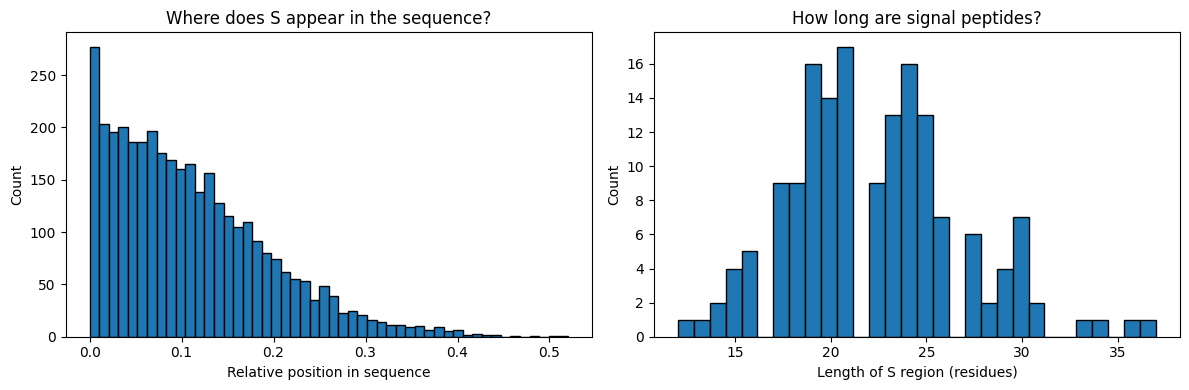

In [37]:
relative_positions, s_lengths = analyze_signal_peptide_position(train_dataset_fused_80)

# plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(relative_positions, bins=50, edgecolor="black")
axes[0].set_xlabel("Relative position in sequence")
axes[0].set_ylabel("Count")
axes[0].set_title("Where does S appear in the sequence?")

axes[1].hist(s_lengths, bins=30, edgecolor="black")
axes[1].set_xlabel("Length of S region (residues)")
axes[1].set_ylabel("Count")
axes[1].set_title("How long are signal peptides?")

plt.tight_layout()
plt.show()

In [39]:
def compute_initial_frequencies(filepath, alphabet="ACDEFGHIKLMNPQRSTVWY"):
    """
    Computes the initial state frequencies from the first position
    of each sequence in a fasta file.

    Parameters
    ----------
    filepath : str
        Path to the fasta file.
    alphabet : str
        Valid amino acid symbols.

    Returns
    -------
    pi : np.ndarray
        Initial state probability vector.
    """

    label_map = {"S": 0, "I": 1, "M": 2, "B": 3, "P": 4, "O": 5}
    first_states = Counter()

    with open(filepath, "r") as f:
        lines = [l.strip() for l in f.readlines()]

    i = 0
    while i < len(lines):
        if lines[i].startswith(">"):
            lab = lines[i+2]
            first_state = lab[0]
            if first_state in label_map:
                first_states[label_map[first_state]] += 1
            i += 3
        else:
            i += 1

    total = sum(first_states.values())

    print("=== INITIAL STATE FREQUENCIES ===")
    inv_label_map = {v: k for k, v in label_map.items()}
    for state_idx, count in sorted(first_states.items()):
        print(f"  State {inv_label_map[state_idx]} ({state_idx}): {count:4d} ({100*count/total:.2f}%)")

    n_states = max(first_states.keys()) + 1
    pi = np.zeros(n_states)
    for state_idx, count in first_states.items():
        pi[state_idx] = count / total

    print(f"\npi = {np.round(pi, 4)}")
    return pi


pi_empirical = compute_initial_frequencies(train_dataset_fused_80)

=== INITIAL STATE FREQUENCIES ===
  State S (0):  161 (48.64%)
  State I (1):  158 (47.73%)
  State O (5):   12 (3.63%)

pi = [0.4864 0.4773 0.     0.     0.     0.0363]
